In [1]:
from dk_model import DeepKrigingTrainer
import pandas as pd 
import numpy as np
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
import gstools as gs
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from gstools import Exponential, Stable, vario_estimate_unstructured, Cubic, Gaussian
import matplotlib.pyplot as plt
#import pyarrow.feather as feather
import yaml


In [ ]:
#load model parameters from yaml file
with open('model_pars.yaml', 'r') as file:
    model_params = yaml.safe_load(file)

#Access parameters


mineral = model_params['response']
#mineral = tuple(mineral)  # Convert to tuple for consistency
covariates = model_params['covariates']
#covariates = tuple(covariates)  # Convert to tuple for consistency

#model_params = model_params['model']

learning_rate = model_params['learning_rate']
batch_size = model_params['batch_size']
epochs = model_params['epochs']
cellsize = model_params['cellsize']
layers = model_params['layers']
dropout = model_params['dropout']
activation = model_params['activation']
loss = model_params['loss']
optimizer = model_params['optimizer']

x = model_params['x']
y = model_params['y']
z = model_params['z']

# plotting parameters
cov_labels = model_params['cov_labels']

# file paths
source_dir = model_params['source_dir']
working_dir = model_params['working_dir']

In [3]:
# remember to change the filename to be the one you want to load

deposit_data = pd.read_csv(f'{working_dir}/final_dataset.csv', low_memory=False)
#deposit_data = pd.read_csv(f'{working_dir}/final_dataset_1level.csv', low_memory=False)
un_norm_deposit_data = pd.read_csv(f'{working_dir}/filtered_unnormalised_deposit_data.csv', low_memory=False)


In [5]:
# sample for testing 
sub_un_norm_deposit_data = un_norm_deposit_data.copy()
sub_deposit_data = deposit_data.copy()

#sub_un_norm_deposit_data = un_norm_deposit_data.sample(n=6000, random_state=42)
#sub_deposit_data = deposit_data.sample(n=6000, random_state=42)



<Figure size 800x600 with 0 Axes>

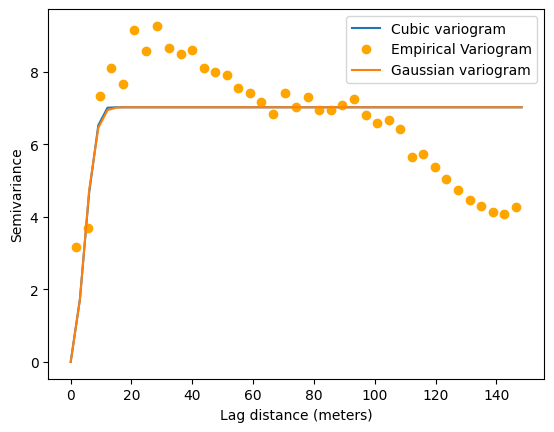

Cubic Model Parameters:
Cubic(dim=3, var=7.02, len_scale=13.8, nugget=0.0)

Gaussian Model Parameters:
Gaussian(dim=3, var=7.02, len_scale=5.08, nugget=0.0)


In [6]:
X = sub_un_norm_deposit_data[x].values
Y = sub_un_norm_deposit_data[y].values
Z = sub_un_norm_deposit_data[z].values
#density = dens_data['Density_gcm3'].values
density = sub_un_norm_deposit_data[mineral].values

max_dist = np.max([X.max()-X.min(), Y.max()-Y.min(), Z.max()-Z.min()]) / 4.3
bins = np.linspace(0, max_dist, 40)

bin_center, gamma = vario_estimate_unstructured((X, Y, Z), density, bins)

cubic_model = Cubic(dim=3)
cubic_model.fit_variogram(bin_center, gamma, nugget=False)

gaussian_model = Gaussian(dim=3)
gaussian_model.fit_variogram(bin_center, gamma, nugget=False)

plt.figure(figsize=(8, 6))

ax = cubic_model.plot(x_max=bins.max(), label="Cubic variogram")
# Add the empirical variogram
ax.plot(bin_center, gamma, 'o', label='Empirical Variogram', color='orange')

gaussian_model.plot(ax=ax, x_max=bins.max(), label="Gaussian variogram")

ax.set_xlabel('Lag distance (meters)')
ax.set_ylabel('Semivariance')
plt.legend()

plt.show()

print("Cubic Model Parameters:")
print(cubic_model)
print("\nGaussian Model Parameters:")
print(gaussian_model)


In [15]:
# find basis function columns. These have the prefix 'phi_'
idx_phi_columns = [col for col in sub_deposit_data.columns if col.startswith('phi_')]
num_basis_functions = len(idx_phi_columns)

#print(f'{num_basis_functions} basis function columns found')

#find the first phi columns
first_phi = idx_phi_columns[0] if idx_phi_columns else None
# Get the integer column location (index position)
D = sub_deposit_data.columns.get_loc(first_phi) if first_phi else None

print(D)



#phi_columns = deposit_data[idx_phi_columns].values


10


# 1. Deepkriging and DNN

In [8]:
# playing around with covariates
#deposit_data[covariates]
covariates = covariates[0:2]

#covariates = covariates.remove('Lith1_Code')
#covariates_test = covariates[0:4]

In [25]:
print("Metrics for Deepkriging")
#trainer = DeepKrigingTrainer(deposit_data, regular_nn=False, plot_errors=True, phi_columns=idx_phi_columns)
trainer = DeepKrigingTrainer(deposit_data, regular_nn=False, spatial_coords=[x ,y ,z], plot_errors=False, phi_columns=D)
trainer.train_neural_network()



print("\nMetrics for regular DNN")
trainer = DeepKrigingTrainer(deposit_data, regular_nn=True, spatial_coords=[x, y, z], plot_errors=True, phi_columns=None)
trainer.train_neural_network()



print("\nMetrics for Deepkriging with covariates")
trainer = DeepKrigingTrainer(deposit_data, covariates, regular_nn=False, spatial_coords=[x, y, z], plot_errors=False, phi_columns=D)
trainer.train_neural_network()

# Covariates in regular DNN not using categorical variables at the moment due to an error 



print("\nMetrics for regular DNN with covariates")
trainer = DeepKrigingTrainer(deposit_data, covariates, regular_nn=True, spatial_coords=[x, y, z], plot_errors=False, phi_columns=D)
trainer.train_neural_network()


Metrics for Deepkriging

Average Metrics Across Folds:
  Average MSE: 0.0002
  Average MAE: 0.0045
  Average Adjusted R2: 0.1785
  Average R2: 0.2282

Metrics for regular DNN

Average Metrics Across Folds:
  Average MSE: 0.0002
  Average MAE: 0.0049
  Average Adjusted R2: 0.1458
  Average R2: 0.1470

Metrics for Deepkriging with covariates

Average Metrics Across Folds:
  Average MSE: 0.0002
  Average MAE: 0.0030
  Average Adjusted R2: -0.0076
  Average R2: 0.0558

Metrics for regular DNN with covariates

Average Metrics Across Folds:
  Average MSE: 0.0005
  Average MAE: 0.0033
  Average Adjusted R2: -1.3649
  Average R2: -1.3557


# 2. Reg kriging 

In [ ]:
np.random.seed(42)
'''

'''
Y = sub_deposit_data[mineral].values
X = sub_deposit_data[[x]+[y]+[z]+covariates].values



num_folds = 10
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

mse_list, mae_list, adjusted_r2_list, r2_list = [], [], [], []

for train_index, test_index in kf.split(X):
    X_cv_train, X_cv_test = X[train_index], X[test_index]
    y_cv_train, y_cv_test = Y[train_index], Y[test_index]

    regression_model = LinearRegression()
    regression_model.fit(X_cv_train, y_cv_train)

    y_cv_pred = regression_model.predict(X_cv_test)

    residuals_train = y_cv_train - regression_model.predict(X_cv_train).flatten()
#Linear
    model = gs.Cubic(dim=3)
    krige = gs.krige.Ordinary(model, cond_pos=[X_cv_train[:, 0], X_cv_train[:, 1], X_cv_train[:, 2]], cond_val=residuals_train, fit_variogram=True)

    kriging_pred, kriging_var = krige([X_cv_test[:, 0], X_cv_test[:, 1], X_cv_test[:, 2]], return_var=True)

    final_cv_predictions = y_cv_pred.flatten() + kriging_pred

    mse = mean_squared_error(y_cv_test, final_cv_predictions)
    mae = mean_absolute_error(y_cv_test, final_cv_predictions)
    
    sst = np.sum((y_cv_test - np.mean(y_cv_test)) ** 2)
    ssr = np.sum((y_cv_test - final_cv_predictions) ** 2)
    r2 = 1 - (ssr / sst)
    
    n = len(y_cv_test)
    num_predictors = X_cv_test.shape[1]
    adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - num_predictors - 1))

    mse_list.append(mse)
    mae_list.append(mae)
    adjusted_r2_list.append(adjusted_r2)
    r2_list.append(r2)

print("Metrics for regression kriging with covariates")
print("\nAverage Metrics Across Folds:")
print(f"  Average MSE: {np.mean(mse_list):.4f}")
print(f"  Average MAE: {np.mean(mae_list):.4f}")
print(f"  Average adjusted R2: {np.mean(adjusted_r2_list):.4f}")
print(f"  Average R2: {np.mean(r2_list):.4f}")


Metrics for regression kriging with covariates

Average Metrics Across Folds:
  Average MSE: 0.0001
  Average MAE: 0.0028
  Average adjusted R2: 0.4421
  Average R2: 0.4467


In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression

np.random.seed(42)

covariance_models = {
    "Gaussian": gs.Gaussian(dim=3),
    "Matern": gs.Matern(dim=3),
    "Integral": gs.Integral(dim=3),
    "Rational": gs.Rational(dim=3),
    "Cubic": gs.Cubic(dim=3),
}
'''
Y = deposit_data[mineral].values
X = deposit_data[[x]+[y]+[z]+covariates].values
'''

Y = sub_deposit_data[mineral].values
X = sub_deposit_data[[x]+[y]+[z]+covariates].values


num_folds = 10
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

results = {}

# Loop over each covariance model
for model_name, model in covariance_models.items():
    mse_list, mae_list, adjusted_r2_list = [], [], []

    for train_index, test_index in kf.split(X):
        X_cv_train, X_cv_test = X[train_index], X[test_index]
        y_cv_train, y_cv_test = Y[train_index], Y[test_index]

        regression_model = LinearRegression()
        regression_model.fit(X_cv_train, y_cv_train)

        y_cv_pred = regression_model.predict(X_cv_test)
        residuals_train = y_cv_train - regression_model.predict(X_cv_train).flatten()

        krige = gs.krige.Ordinary(model, cond_pos=[X_cv_train[:, 0], X_cv_train[:, 1], X_cv_train[:, 2]], 
                                  cond_val=residuals_train, fit_variogram=True)

        kriging_pred, kriging_var = krige([X_cv_test[:, 0], X_cv_test[:, 1], X_cv_test[:, 2]], return_var=True)

        final_cv_predictions = y_cv_pred.flatten() + kriging_pred

        mse = mean_squared_error(y_cv_test, final_cv_predictions)
        mae = mean_absolute_error(y_cv_test, final_cv_predictions)
        
        sst = np.sum((y_cv_test - np.mean(y_cv_test)) ** 2)
        ssr = np.sum((y_cv_test - final_cv_predictions) ** 2)
        r2 = 1 - (ssr / sst)

        n = len(y_cv_test)
        num_predictors = X_cv_test.shape[1]
        adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - num_predictors - 1))

        mse_list.append(mse)
        mae_list.append(mae)
        adjusted_r2_list.append(adjusted_r2)

    # Store the mean metrics for the current model
    results[model_name] = {
        "mean_mse": np.mean(mse_list),
        "mean_mae": np.mean(mae_list),
        "mean_adjusted_r2": np.mean(adjusted_r2_list)
    }

    # Print results for the current model
    print(f"Metrics for regression kriging with {model_name} covariance model:")
    print(f"  Average MSE: {np.mean(mse_list):.4f}")
    print(f"  Average MAE: {np.mean(mae_list):.4f}")
    print(f"  Average adjusted R2: {np.mean(adjusted_r2_list):.4f}")
    print()



Metrics for regression kriging with Gaussian covariance model:
  Average MSE: 0.0001
  Average MAE: 0.0030
  Average adjusted R2: 0.4380

Metrics for regression kriging with Matern covariance model:
  Average MSE: 0.0001
  Average MAE: 0.0030
  Average adjusted R2: 0.4302

Metrics for regression kriging with Integral covariance model:
  Average MSE: 0.0001
  Average MAE: 0.0029
  Average adjusted R2: 0.4395

Metrics for regression kriging with Rational covariance model:
  Average MSE: 0.0001
  Average MAE: 0.0030
  Average adjusted R2: 0.4382

Metrics for regression kriging with Cubic covariance model:
  Average MSE: 0.0001
  Average MAE: 0.0028
  Average adjusted R2: 0.4421



# Kriging 

In [26]:
np.random.seed(42)

'''
Y = deposit_data[mineral].values.flatten()
X = deposit_data[[x]+[y]+[z]].values
'''


Y = sub_deposit_data[mineral].values.flatten()
X = sub_deposit_data[[x]+[y]+[z]].values



mse_list = []
mae_list = []
test_adjusted_r2_list = []
r2_list = []

num_folds = 10
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

for train_index, test_index in kf.split(X):
    X_cv_train, X_cv_test = X[train_index], X[test_index]
    y_cv_train, y_cv_test = Y[train_index], Y[test_index]

    model = gs.Gaussian(dim=3)
    krige = gs.krige.Ordinary(model, cond_pos=[X_cv_train[:, 0], X_cv_train[:, 1], X_cv_train[:, 2]], cond_val=y_cv_train, fit_variogram=True)

    kriging_pred, kriging_var = krige([X_cv_test[:, 0], X_cv_test[:, 1], X_cv_test[:, 2]], return_var=True)

    final_cv_predictions = kriging_pred

    mse = mean_squared_error(y_cv_test, final_cv_predictions)
    mae = mean_absolute_error(y_cv_test, final_cv_predictions)
    mse_list.append(mse)
    mae_list.append(mae)

    n = len(y_cv_test)
    sst = np.sum((y_cv_test - np.mean(y_cv_test)) ** 2)
    ssr = np.sum((y_cv_test - final_cv_predictions) ** 2)
    r2 = 1 - (ssr / sst)

    num_predictors = X_cv_test.shape[1]
    adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - num_predictors - 1))
    test_adjusted_r2_list.append(adjusted_r2)
    r2_list.append(r2)
# Calculate mean metrics across folds
mean_mse = np.mean(mse_list)
mean_mae = np.mean(mae_list)
mean_a_r2 = np.mean(test_adjusted_r2_list)
mean_r2 = np.mean(r2_list)

print("Metrics for 3D kriging")
print(f"  Average MSE: {mean_mse:.5f}")
print(f"  Average MAE: {mean_mae:.5f}")
print(f"  Average adjusted R2: {mean_a_r2:.5f}")
print(f"  Average R2: {mean_r2:.5f}")


Metrics for 3D kriging
  Average MSE: 0.00016
  Average MAE: 0.00428
  Average adjusted R2: 0.27169
  Average R2: 0.27275


In [27]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import KFold

# Seed for reproducibility
np.random.seed(42)

# Define covariance models
covariance_models = {
    "Gaussian": gs.Gaussian(dim=3),
    "Rational": gs.Rational(dim=3),
    "Cubic": gs.Cubic(dim=3),
}
'''
Y = deposit_data[mineral].values.flatten()
X = deposit_data[[x]+[y]+[z]].values
'''

Y = sub_deposit_data[mineral].values.flatten()
X = sub_deposit_data[[x]+[y]+[z]].values




num_folds = 10
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

results = {}

for model_name, model in covariance_models.items():
    mse_list = []
    mae_list = []
    test_adjusted_r2_list = []

    for train_index, test_index in kf.split(X):
        X_cv_train, X_cv_test = X[train_index], X[test_index]
        y_cv_train, y_cv_test = Y[train_index], Y[test_index]

        krige = gs.krige.Ordinary(model, cond_pos=[X_cv_train[:, 0], X_cv_train[:, 1], X_cv_train[:, 2]], 
                                  cond_val=y_cv_train, fit_variogram=True)

        kriging_pred, kriging_var = krige([X_cv_test[:, 0], X_cv_test[:, 1], X_cv_test[:, 2]], return_var=True)

        final_cv_predictions = kriging_pred

        mse = mean_squared_error(y_cv_test, final_cv_predictions)
        mae = mean_absolute_error(y_cv_test, final_cv_predictions)
        mse_list.append(mse)
        mae_list.append(mae)

        n = len(y_cv_test)
        sst = np.sum((y_cv_test - np.mean(y_cv_test)) ** 2)
        ssr = np.sum((y_cv_test - final_cv_predictions) ** 2)
        r2 = 1 - (ssr / sst)

        num_predictors = X_cv_test.shape[1]
        adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - num_predictors - 1))
        test_adjusted_r2_list.append(adjusted_r2)

    mean_mse = np.mean(mse_list)
    mean_mae = np.mean(mae_list)
    mean_a_r2 = np.mean(test_adjusted_r2_list)

    results[model_name] = {
        "mean_mse": mean_mse,
        "mean_mae": mean_mae,
        "mean_adjusted_r2": mean_a_r2
    }

    # Print results for the current model
    print(f"Metrics for {model_name} covariance model:")
    print(f"  Average MSE: {mean_mse:.5f}")
    print(f"  Average MAE: {mean_mae:.5f}")
    print(f"  Average adjusted R2: {mean_a_r2:.5f}")



Metrics for Gaussian covariance model:
  Average MSE: 0.00016
  Average MAE: 0.00428
  Average adjusted R2: 0.27169
Metrics for Rational covariance model:
  Average MSE: 0.00016
  Average MAE: 0.00427
  Average adjusted R2: 0.27229
Metrics for Cubic covariance model:
  Average MSE: 0.00015
  Average MAE: 0.00383
  Average adjusted R2: 0.32833
